<font color="#0D47A1" size="6">
<b>Análise e Previsão de Inadimplência de Clientes de Cartão de Crédito</b>

</font>



<font color="#1565C0" size="5">
<b>1. Problema de Negócio</b>
</font>

- Instituições financeiras analisam diariamente um grande volume de solicitações de empréstimo. Esse processo envolve avaliar diversas informações do cliente, como renda, escolaridade, patrimônio, histórico financeiro e capacidade de pagamento.

- Diante desse cenário, modelos de Machine Learning podem auxiliar na identificação de padrões presentes nos dados históricos, apoiando decisões de concessão de crédito de forma mais eficiente e consistente.

<font color="#1565C0" size="5">
<b>2. Objetivo </b>
</font>

- Desenvolver um modelo de classificação capaz de prever se uma solicitação de empréstimo será aprovada ou rejeitada com base nas características do solicitante.

- Para isso, foram realizadas as etapas de limpeza e preparação dos dados, análise exploratória, treinamento de modelos de Machine Learning e avaliação de desempenho, buscando identificar o algoritmo com melhor capacidade preditiva.

<font color="#1565C0" size="5">
<b>3. Público Alvo</b>
</font>

Este projeto é direcionado a profissionais e organizações que atuam na análise e concessão de crédito, como:

- Bancos;
- Fintechs;
- Cooperativas de crédito;
- Instituições financeiras;
- Analistas e gestores de risco de crédito;
- Equipes de Ciência e Análise de Dados que desenvolvem soluções para apoiar decisões de concessão de empréstimos.

O modelo tem como objetivo servir como ferramenta de apoio à decisão, contribuindo para análises mais rápidas, consistentes e baseadas em dados.

<font color="#1565C0" size="5">
<b>4. Importando as Bibliotecas</b>
</font>

In [ ]:
# Bibliotecas gerais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Configuração visual dos gráficos
sns.set_theme(style='whitegrid')
sns.set_palette('pastel')

<font color="#1565C0" size="5">
<b>5. Conhecendo os Dados</b>
</font>

  Nesta etapa é realizada uma inspeção inicial da base de dados para compreender sua estrutura, verificar a qualidade das informações e identificar possíveis inconsistências antes das análises exploratórias e da construção dos modelos preditivos.

In [ ]:
# Carregamento Dataset
from google.colab import files

uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card (6).csv


In [ ]:
# Lendo dataset e atribuindo a ele uma variável
df = pd.read_csv('/content/UCI_Credit_Card.csv')

In [ ]:
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [ ]:
# Número de registros e variáveis
print(f'Número de registros: {df.shape[0]}')
print(f'Número de variáveis: {df.shape[1]}')

Número de registros: 30000
Número de variáveis: 25


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2                   300

In [ ]:
# Verificando existência de registros duplicados
df.duplicated().sum()

np.int64(0)

In [ ]:
# Verificando existência de valores nulos
df.isnull().sum()

,0
ID,0
LIMIT_BAL,0
SEX,0
EDUCATION,0
MARRIAGE,0
AGE,0
PAY_0,0
PAY_2,0
PAY_3,0
PAY_4,0


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


**Notas**

- A inspeção inicial da base de dados demonstrou que o conjunto de dados possui **30.000 registros** e **25 variáveis**, oferecendo um volume adequado para o desenvolvimento de modelos de classificação.
- A análise revelou que não existem valores ausentes nem registros duplicados, indicando boa qualidade dos dados para as etapas seguintes.
- Além disso, as estatísticas descritivas mostraram ampla variação em variáveis financeiras, como limite de crédito, valores de fatura e pagamentos realizados, sugerindo a presença de diferentes perfis de clientes. Essas diferenças poderão ser exploradas na Análise Exploratória de Dados (EDA) para identificar padrões e compreender quais características possuem maior influência na previsão da inadimplência.

<font color="#1565C0" size="5">
<b>6. Análise Exploratória dos Dados (EDA)</b>
</font>

Nesta etapa são exploradas as principais características da base de dados por meio de análises gráficas e estatísticas. O objetivo é compreender a distribuição das variáveis, identificar padrões, verificar possíveis outliers e investigar relações que possam influenciar a previsão da inadimplência.

<font color="#1565C0" size="4">
<b>6.1 Distribuição das variáveis numéricas</b>
</font>

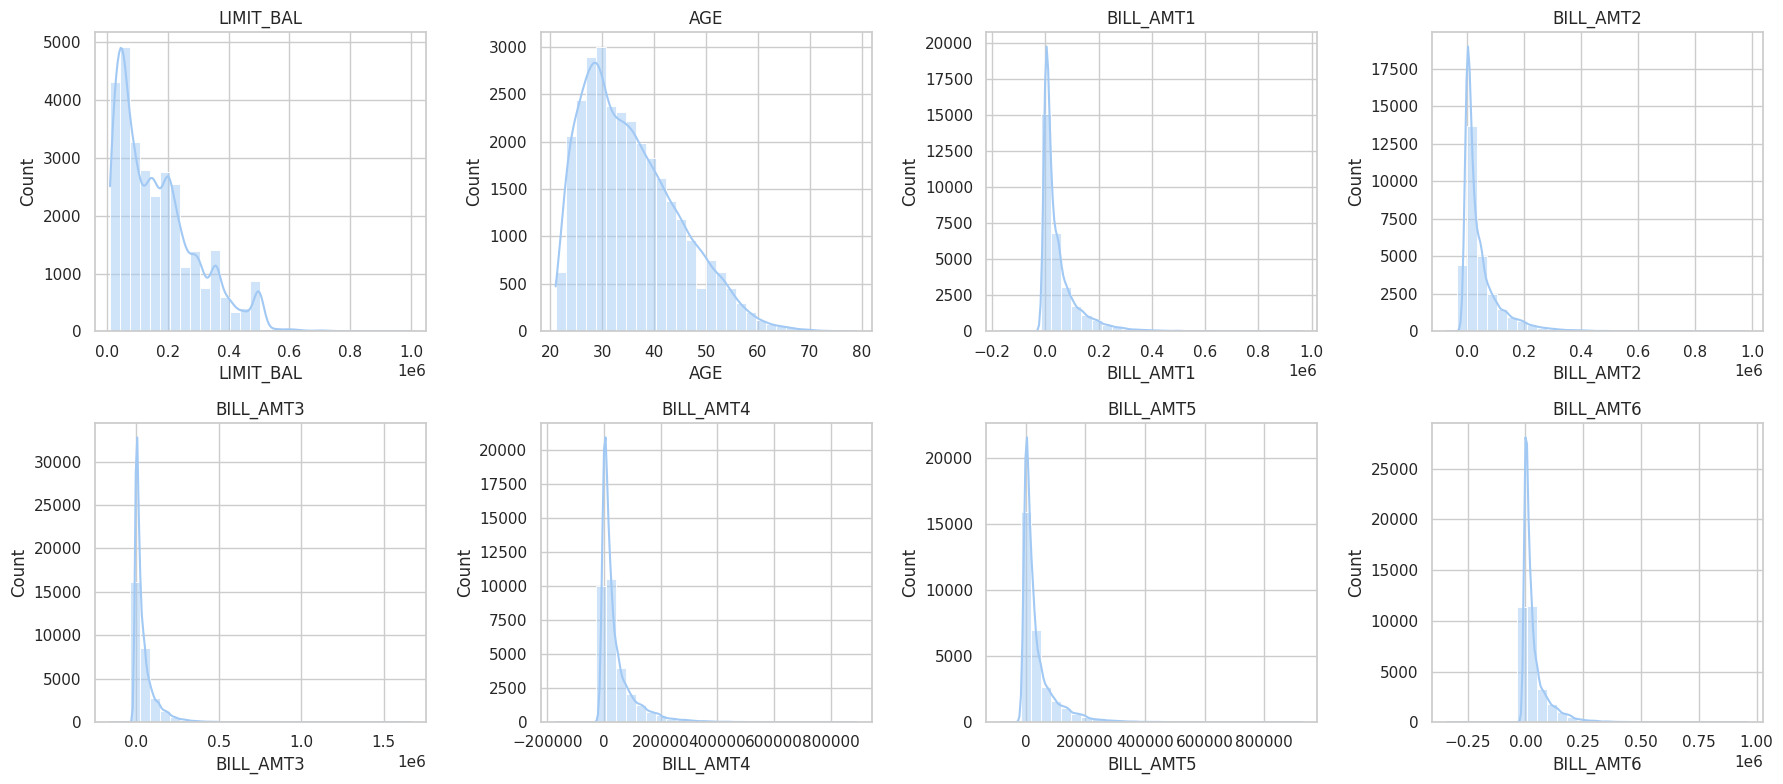

In [ ]:
cols = [
'LIMIT_BAL','AGE',
'BILL_AMT1','BILL_AMT2','BILL_AMT3',
'BILL_AMT4','BILL_AMT5','BILL_AMT6'
]

fig, axes = plt.subplots(2,4, figsize=(18,8))

for ax, coluna in zip(axes.flatten(), cols):

    sns.histplot(df[coluna],
                 bins=30,
                 kde=True,
                 ax=ax)

    ax.set_title(coluna)

plt.tight_layout()

**Notas**

- A distribuição das variáveis financeiras, como limite de crédito (LIMIT_BAL), valores das faturas (BILL_AMT) e pagamentos realizados (PAY_AMT), apresenta forte assimetria à direita. Isso indica que a maior parte dos clientes possui valores relativamente baixos, enquanto um número reduzido concentra valores elevados.

- A variável AGE apresenta distribuição mais próxima de uma curva unimodal, concentrando clientes entre aproximadamente 25 e 40 anos.

<font color="#1565C0" size="4">
<b>6.2 Identificação de Outliers</b>
</font>

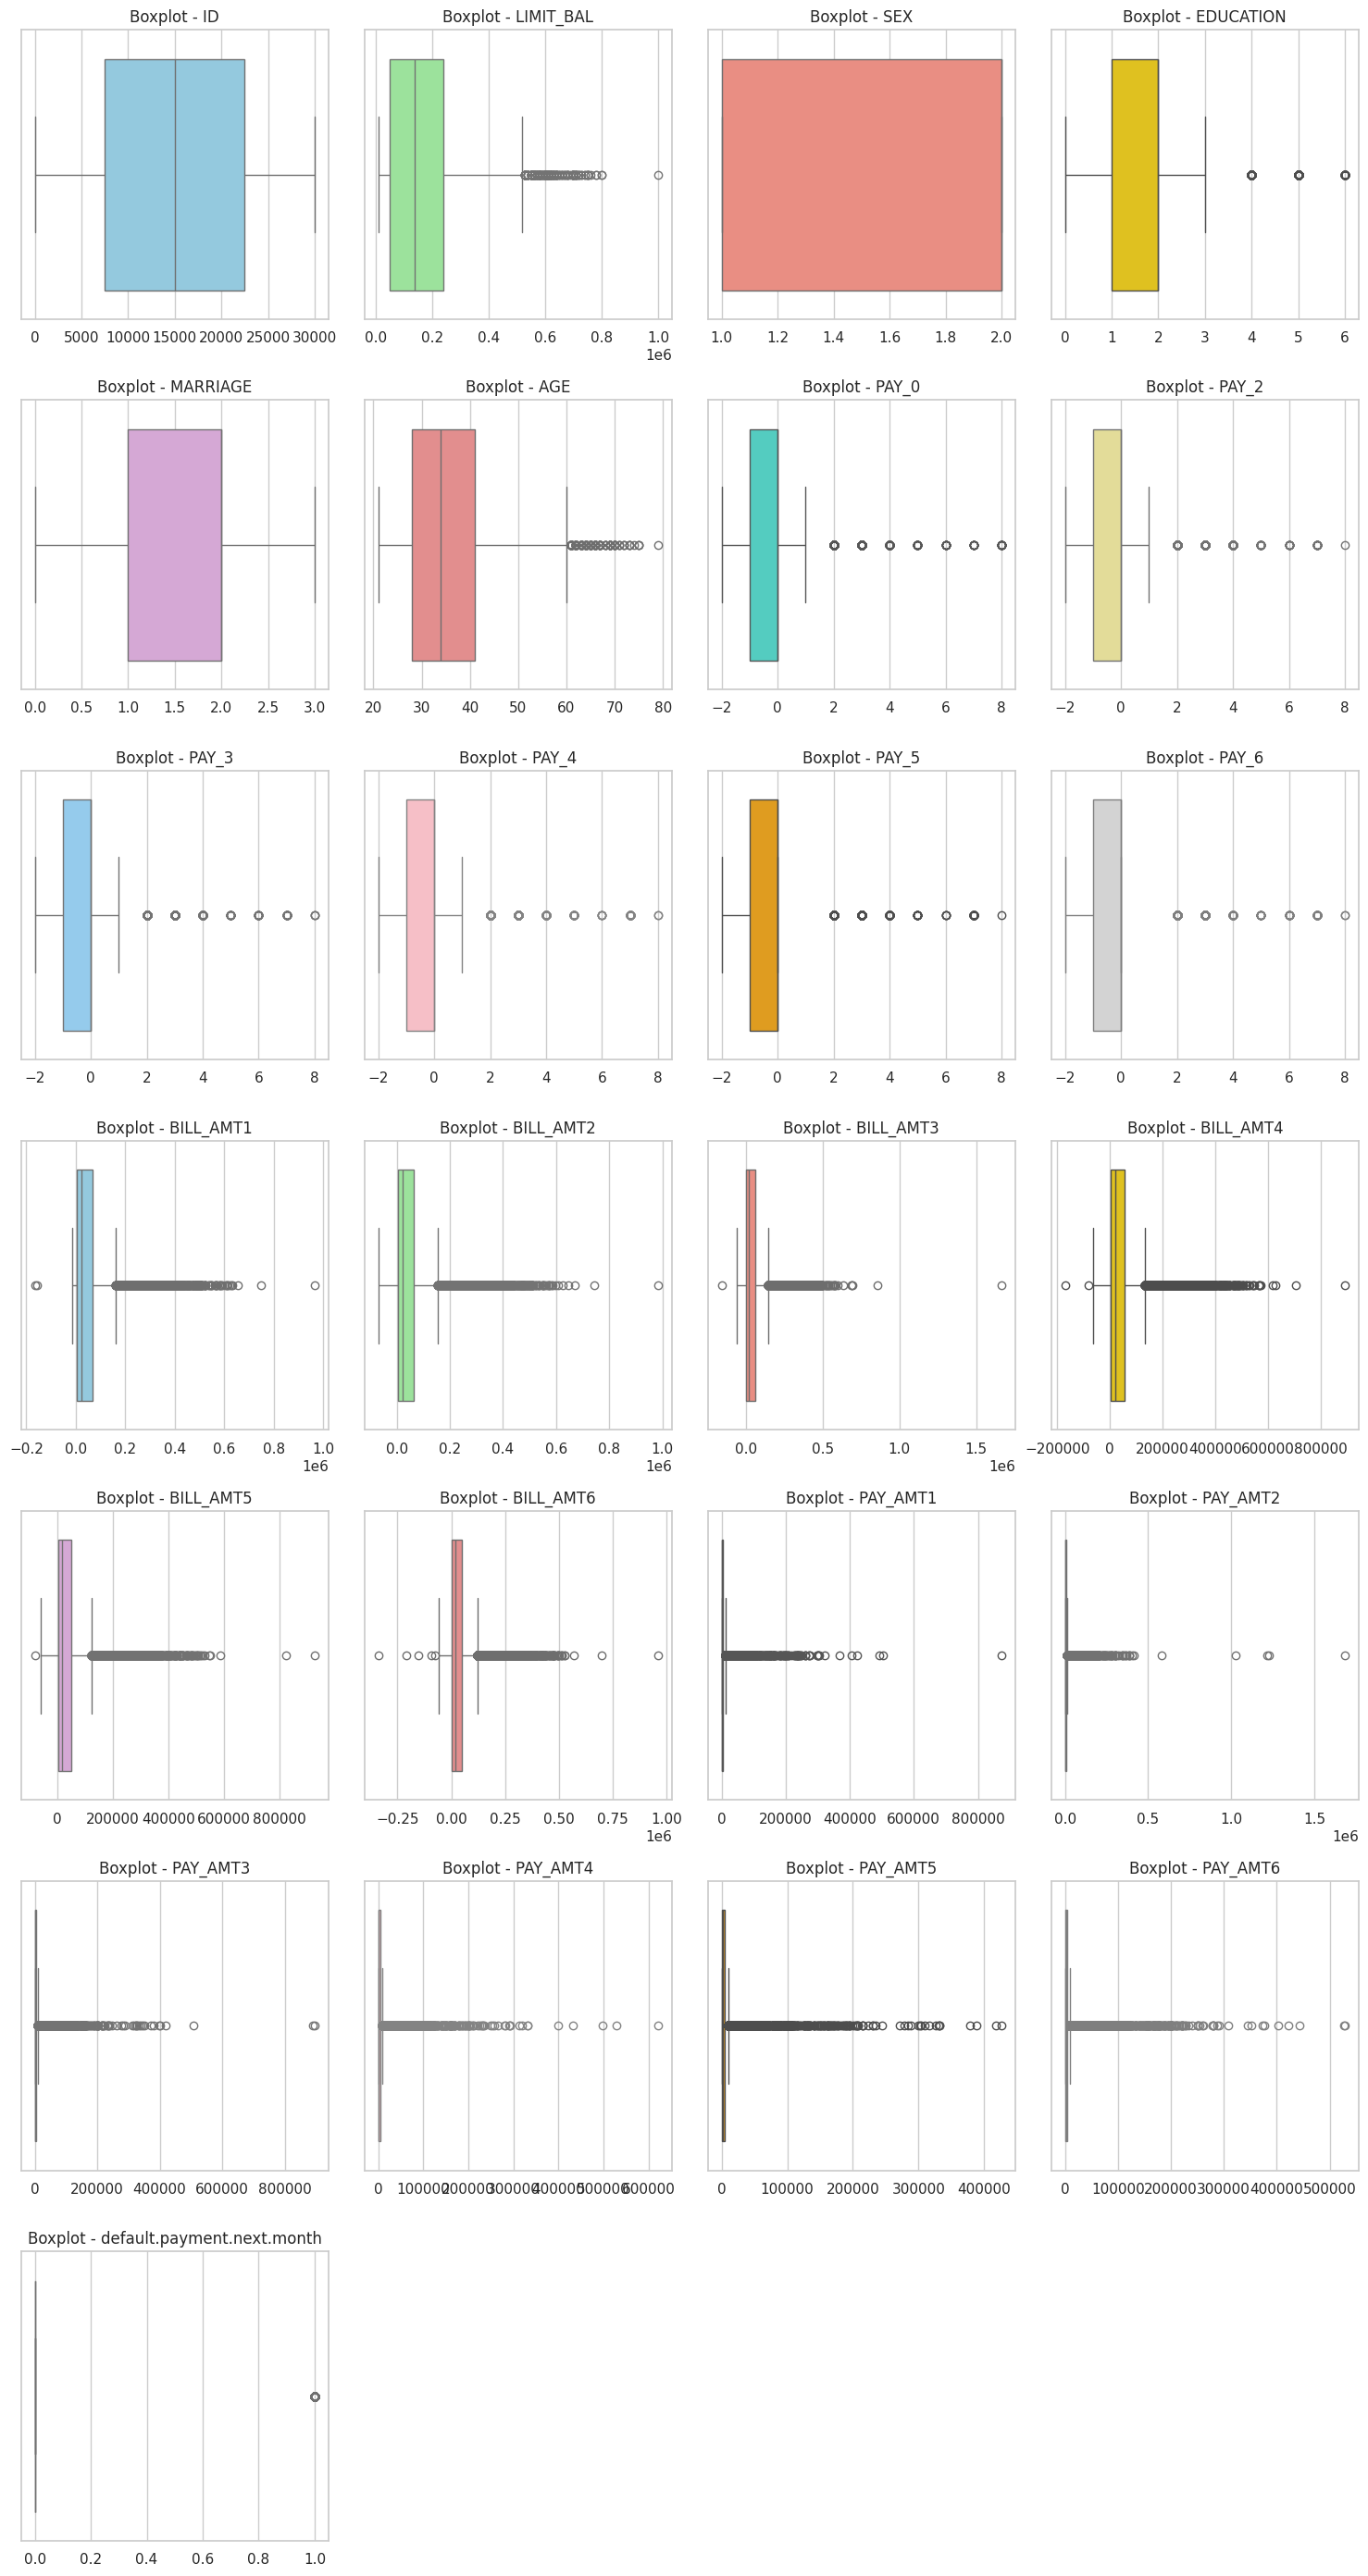

In [ ]:
# Gráficos de Outliers
# Seleciona apenas as colunas numéricas
colunas_numericas = df.select_dtypes(include=['int64', 'float64']).columns

# Lista de cores
cores = ['skyblue', 'lightgreen', 'salmon',
         'gold', 'plum', 'lightcoral',
         'turquoise', 'khaki', 'lightskyblue',
         'lightpink', 'orange', 'lightgray']

# Define a quantidade de linhas e colunas
n_cols = 4
n_rows = math.ceil(len(colunas_numericas) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

# Cria os boxplots
for i, coluna in enumerate(colunas_numericas):
    sns.boxplot(
        x=df[coluna],
        ax=axes[i],
        color=cores[i % len(cores)]
    )
    axes[i].set_title(f'Boxplot - {coluna}')
    axes[i].set_xlabel('')

# Remove eixos vazios
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Notas**

- Os boxplots evidenciam a presença de diversos valores extremos, principalmente nas variáveis financeiras relacionadas ao limite de crédito, valores de fatura e pagamentos realizados.

- Esses outliers podem representar clientes com alto poder aquisitivo ou limites de crédito elevados, não sendo necessariamente erros de coleta. Portanto, optou-se por manter esses registros para preservar características importantes do problema de negócio.

<font color="#1565C0" size="4">
<b>6.3 Análise de Correlaçãos</b>
</font>

<Axes: >

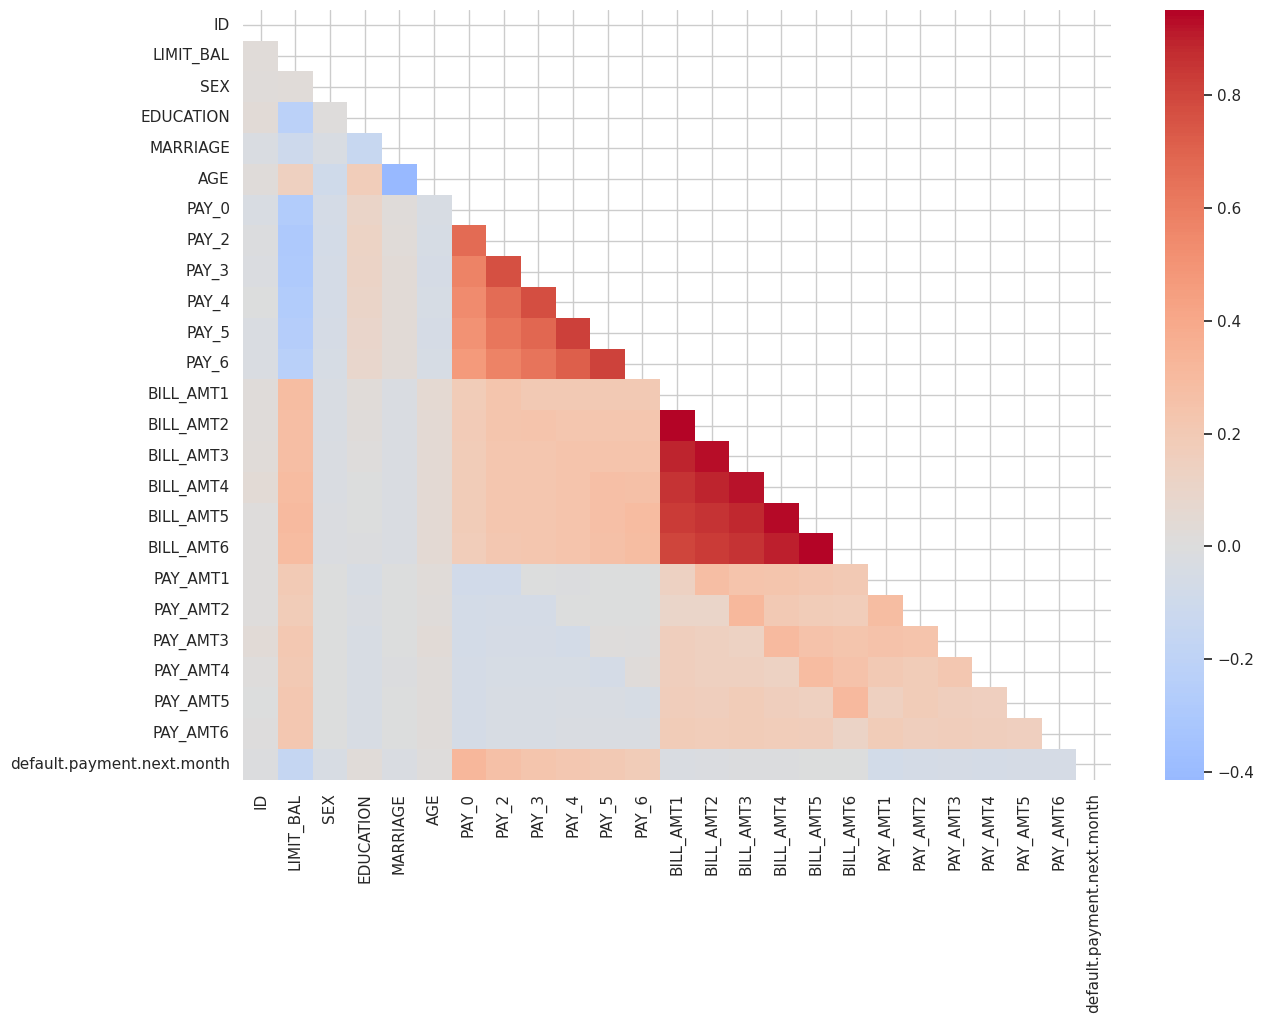

In [ ]:
# Gráfico de Correlações
corr = df.corr(numeric_only=True)

mask = np.triu(np.ones_like(corr))

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0
)

**Notas**

- Observa-se forte correlação positiva entre os valores das faturas mensais (BILL_AMT1 a BILL_AMT6), indicando que clientes com maiores saldos em um mês tendem a apresentar comportamento semelhante nos meses seguintes.

- Também é possível identificar correlações moderadas entre o histórico de atrasos (PAY_0 a PAY_6), sugerindo que atrasos recorrentes tendem a persistir ao longo do tempo.

- As demais variáveis apresentam correlações mais baixas, indicando que podem fornecer informações complementares ao modelo preditivo.

<font color="#1565C0" size="4">
<b>6.4 Distribuição da variável alvo</b>
</font>

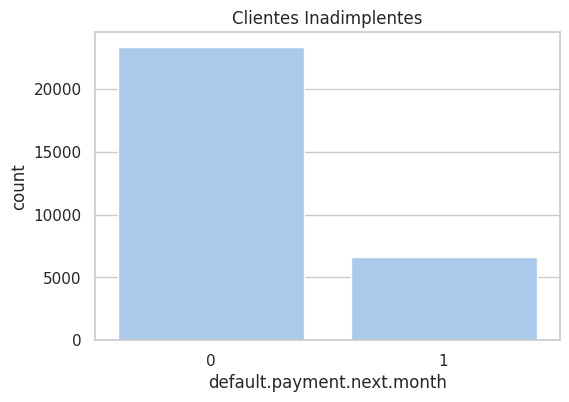

In [ ]:
# Distribuição da variável alvo
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='default.payment.next.month'
)

plt.title("Clientes Inadimplentes")

plt.show()

In [ ]:
# Contagem de clientes por classe
df['default.payment.next.month'].value_counts()

,count
default.payment.next.month,
0,23364
1,6636


In [ ]:
# Proporção de clientes por classe (%)
(df['default.payment.next.month'].value_counts(normalize=True)*100).round(2)

,proportion
default.payment.next.month,
0,77.88
1,22.12


**Notas**

- A base apresenta desbalanceamento moderado entre as classes. Aproximadamente **77,88%** dos clientes não se tornaram inadimplentes no mês seguinte, enquanto **22,12%** apresentaram inadimplência.

- Esse desbalanceamento deve ser considerado durante a avaliação dos modelos, tornando métricas como Precision, Recall e F1-Score mais informativas do que apenas a acurácia.

<font color="#1565C0" size="5">
<b>7.  Modelos de Machine Learning</b>
</font>

Nesta etapa são preparados os dados para treinamento dos modelos de Machine Learning. Em seguida, são treinados e avaliados dois algoritmos de classificação (Random Forest e XGBoost), comparando seu desempenho na previsão da inadimplência dos clientes.

<font color="#1565C0" size="4">
<b>7.1 Preparação dos dados</b>
</font>

As variáveis preditoras (X) e a variável alvo (y) são separadas para permitir o treinamento dos modelos. Em seguida, os dados são divididos em conjuntos de treino e teste, garantindo que o desempenho seja avaliado em dados não utilizados durante o treinamento.

In [ ]:
# Separar variável alvo
X = df.drop('default.payment.next.month', axis=1)
y = df['default.payment.next.month']

In [ ]:
# Transformar variáveis categóricas
X = pd.get_dummies(X, drop_first=True)


In [ ]:
X.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0
1,2,120000.0,2,2,2,26,-1,2,0,0,...,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0
2,3,90000.0,2,2,2,34,0,0,0,0,...,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0
3,4,50000.0,2,2,1,37,0,0,0,0,...,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0


In [ ]:
# Separar treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')

Treino: (24000, 24)
Teste: (6000, 24)


**Notas**

Foi utilizada uma divisão de **80% para treinamento** e **20% para teste**, preservando a proporção das classes por meio do parâmetro `stratify`. Essa estratégia permite avaliar o desempenho do modelo em dados não vistos anteriormente.

<font color="#1565C0" size="4">
<b>7.2 Modelo Random Forest</b>
</font>

O Random Forest é um algoritmo baseado em um conjunto de árvores de decisão, amplamente utilizado em problemas de classificação por sua capacidade de reduzir o overfitting e capturar relações complexas entre as variáveis.

In [ ]:
# Treinar modelo Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

In [ ]:
# Previsões
y_pred = rf.predict(X_test)

In [ ]:
# Avaliação do modelo
from sklearn.metrics import accuracy_score

print("Acurácia:", accuracy_score(y_test, y_pred))

Acurácia: 0.8153333333333334


In [ ]:
# Relatório da Avaliação
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.94      0.89      4673
           1       0.64      0.37      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.74      0.66      0.68      6000
weighted avg       0.80      0.82      0.80      6000



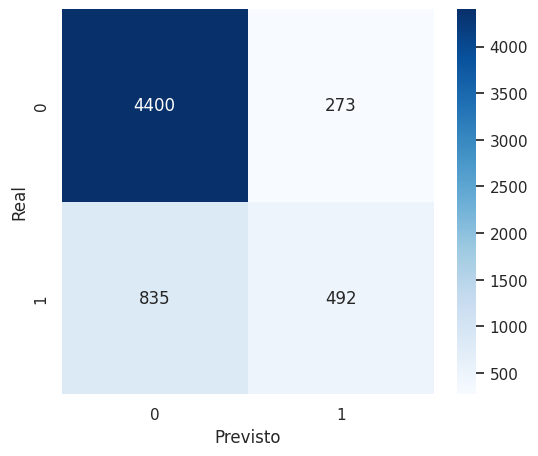

In [ ]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

/tmp/ipykernel_3142/3485884724.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


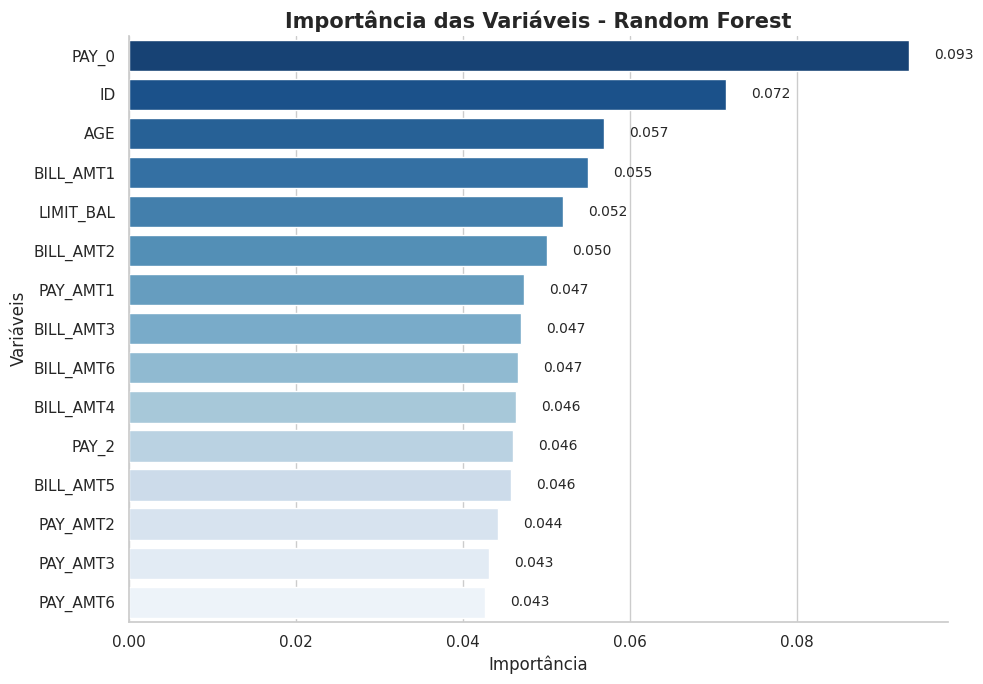

In [ ]:
# Importância das Variáveis - Random Forest

# Cria DataFrame com a importância das variáveis
importancias_rf = pd.DataFrame({
    'Variável': X.columns,
    'Importância': rf.feature_importances_
})

# Ordena da maior para a menor importância
importancias_rf = importancias_rf.sort_values(
    by='Importância',
    ascending=False
)

# Gera o gráfico de barras com as 15 variáveis mais importantes
plt.figure(figsize=(10,7))

ax = sns.barplot(
    data=importancias_rf.head(15),
    x='Importância',
    y='Variável',
    palette='Blues_r'
)

# Adiciona os valores nas barras
for i, valor in enumerate(importancias_rf.head(15)['Importância']):
    ax.text(
        valor + 0.003,
        i,
        f'{valor:.3f}',
        va='center',
        fontsize=10
    )
# Configura o título do gráfico
plt.title(
    'Importância das Variáveis - Random Forest',
    fontsize=15,
    fontweight='bold'
)
# Configura os rótulos dos eixos
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)


# Remove as bordas superior e direita do gráfico
sns.despine()

# Ajusta automaticamente o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()

**Notas**

- O modelo Random Forest apresentou um desempenho satisfatório na classificação dos clientes, alcançando aproximadamente **81,5% de acurácia**.
- A análise das métricas e da matriz de confusão mostra que o algoritmo foi mais eficiente na identificação de clientes adimplentes (classe 0) do que de clientes inadimplentes (classe 1), comportamento esperado devido ao desbalanceamento da base de dados.

- Apesar dessa limitação, o modelo demonstrou boa capacidade de aprendizado e forneceu uma base consistente para comparação com o algoritmo XGBoost.

<font color="#1565C0" size="4">
<b>7.3 Modelo XGBoost</b>
</font>

O XGBoost é um algoritmo de Gradient Boosting que constrói árvores sequencialmente, buscando corrigir os erros cometidos pelas árvores anteriores. É amplamente utilizado em problemas de classificação devido ao seu elevado desempenho.


In [ ]:
# Instalar o XGboost
!pip install xgboost

In [ ]:
# Importar biblioteca
from xgboost import XGBClassifier



In [ ]:
# Criar modelo
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
# Predição
y_pred = xgb.predict(X_test)

In [ ]:
# Relatório da Avaliação
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.93      0.88      4673
           1       0.61      0.36      0.45      1327

    accuracy                           0.81      6000
   macro avg       0.72      0.65      0.67      6000
weighted avg       0.79      0.81      0.79      6000



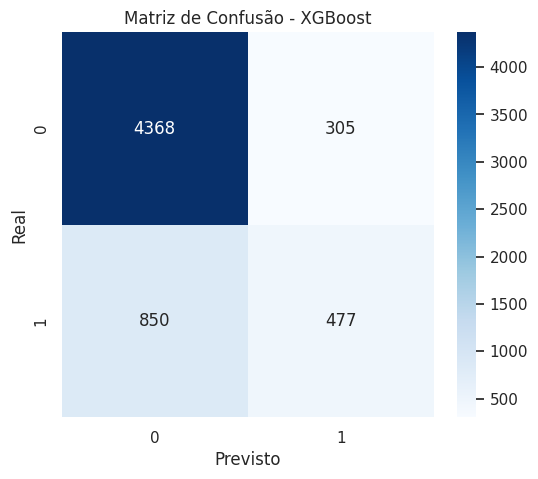

In [ ]:
# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title("Matriz de Confusão - XGBoost")

plt.show()

/tmp/ipykernel_3142/904576508.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


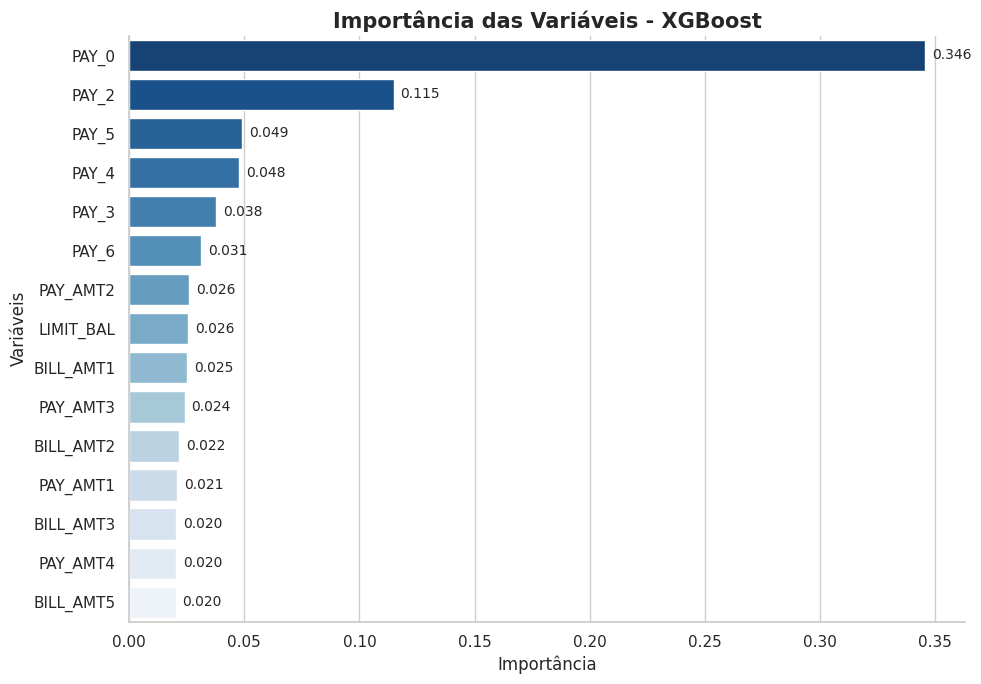

In [ ]:
# Importância das variáveis - XGBoost

# Cria um DataFrame com as variáveis
importancias = pd.DataFrame({
    'Variável': X.columns,
    'Importância': xgb.feature_importances_
})

# Ordena as variáveis da maior para a menor importância
importancias = importancias.sort_values(
    by='Importância',
    ascending=False
)

# Cria a figura do gráfico
plt.figure(figsize=(10, 7))

# Gera o gráfico de barras com as 15 variáveis mais importantes
ax = sns.barplot(
    data=importancias.head(15),
    x='Importância',
    y='Variável',
    palette='Blues_r'
)

# Adiciona os valores de importância ao lado de cada barra
for i, valor in enumerate(importancias.head(15)['Importância']):
    ax.text(
        valor + 0.003,
        i,
        f'{valor:.3f}',
        va='center',
        fontsize=10
    )

# Configura o título do gráfico
plt.title(
    'Importância das Variáveis - XGBoost',
    fontsize=15,
    fontweight='bold'
)

# Configura os rótulos dos eixos
plt.xlabel('Importância', fontsize=12)
plt.ylabel('Variáveis', fontsize=12)

# Remove as bordas superior e direita do gráfico
sns.despine()

# Ajusta automaticamente o layout
plt.tight_layout()

# Exibe o gráfico
plt.show()

<font color="#1565C0" size="4">
<b>7.4 Comparação dos modelos</b>
</font>

Nesta etapa são comparados os resultados obtidos pelos modelos Random Forest e XGBoost por meio das principais métricas de classificação e curvas de desempenho. O objetivo é identificar qual algoritmo apresentou melhor capacidade de prever a inadimplência dos clientes.

<font color="#1565C0" size="4">
<b>7.4.1  Comparação das Métricas</b>
</font>

Nesta seção são comparadas as principais métricas obtidas pelos modelos Random Forest e XGBoost: Accuracy, Precision, Recall e F1-score.

In [ ]:
# Métricas dos modelos

metricas = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Random Forest': [0.8153, 0.64, 0.37, 0.47],
    'XGBoost': [0.8100, 0.61, 0.36, 0.45]
})

metricas

,Métrica,Random Forest,XGBoost
0,Accuracy,0.8153,0.81
1,Precision,0.6400,0.61
2,Recall,0.3700,0.36
3,F1-score,0.4700,0.45


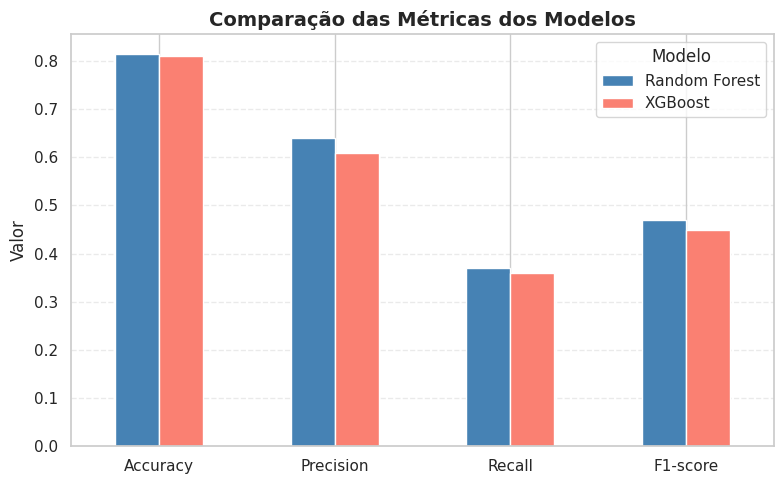

In [ ]:
# Comparação das métricas dos modelos

metricas_plot = metricas.set_index('Métrica')

ax = metricas_plot.plot(
    kind='bar',
    figsize=(8,5),
    color=['steelblue','salmon']
)

plt.title('Comparação das Métricas dos Modelos',
          fontsize=14,
          fontweight='bold')

plt.ylabel('Valor')

plt.xlabel('')

plt.xticks(rotation=0)

plt.legend(title='Modelo')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()

plt.show()

<font color="#1565C0" size="4">
<b>7.4.2 Curva ROC</b>
</font>


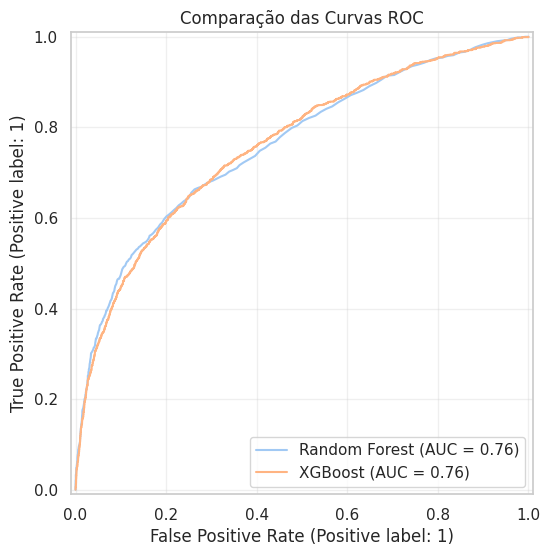

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Comparação das curvas ROC

fig, ax = plt.subplots(figsize=(7,6))

RocCurveDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    ax=ax,
    name='Random Forest'
)

RocCurveDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    ax=ax,
    name='XGBoost'
)

plt.title('Comparação das Curvas ROC')

plt.grid(alpha=0.3)

plt.show()

<font color="#1565C0" size="4">
<b>7.4.3 Curva Precision-Recall</b>
</font>

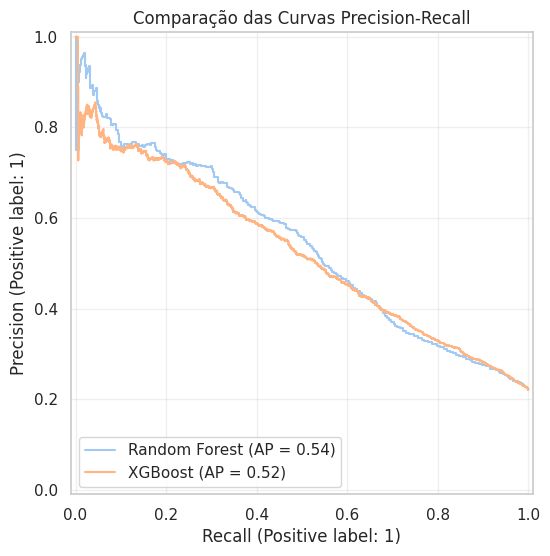

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

# Comparação das curvas Precision-Recall

fig, ax = plt.subplots(figsize=(7,6))

PrecisionRecallDisplay.from_estimator(
    rf,
    X_test,
    y_test,
    ax=ax,
    name='Random Forest'
)

PrecisionRecallDisplay.from_estimator(
    xgb,
    X_test,
    y_test,
    ax=ax,
    name='XGBoost'
)

plt.title('Comparação das Curvas Precision-Recall')

plt.grid(alpha=0.3)

plt.show()

<font color="#1565C0" size="4">
<b>7.4.4 Comparação Final dos Modelos</b>
</font>

- A comparação entre os modelos Random Forest e XGBoost demonstrou que ambos apresentaram desempenho semelhante na tarefa de previsão da inadimplência. O Random Forest obteve resultados ligeiramente superiores nas principais métricas de avaliação, incluindo Accuracy, Precision, Recall e F1-score.

- A análise das Curvas ROC reforçou essa diferença, indicando uma capacidade de discriminação discretamente maior para o Random Forest. Da mesma forma, a Curva Precision-Recall apresentou uma Área Sob a Curva (AP) ligeiramente superior para esse modelo, evidenciando melhor equilíbrio entre precisão e capacidade de identificar corretamente os clientes inadimplentes.

- Considerando o conjunto das métricas e das análises gráficas, o **Random Forest** foi selecionado como o modelo final deste projeto por apresentar o melhor desempenho geral, embora a diferença em relação ao XGBoost tenha sido pequena.

<font color="#1565C0" size="5">
<b>8. Conclusão Geral</b>
</font>

- Ao longo deste projeto, foi possível desenvolver e avaliar modelos de Machine Learning para prever a inadimplência de clientes de cartão de crédito utilizando informações demográficas, financeiras e do histórico de pagamentos.

**Principais resultados**

- Foram realizadas as etapas de preparação dos dados, análise exploratória, treinamento e avaliação de modelos de classificação.
- O modelo selecionado para este projeto foi o **Random Forest**, por apresentar o melhor desempenho geral durante as avaliações.
- Os resultados demonstraram que o histórico recente de pagamentos exerce papel fundamental na previsão da inadimplência.

**Principais insights**

- As variáveis **PAY_0**, **PAY_2**, **PAY_5**, **PAY_4** e **PAY_3** foram as mais relevantes para as previsões do modelo.
- Variáveis relacionadas ao limite de crédito, valores das faturas e pagamentos também contribuíram para a identificação do risco de inadimplência.
- A análise evidenciou que o comportamento financeiro recente é um dos principais indicadores do risco de inadimplência.

**Perspectivas futuras**

- Realizar otimização de hiperparâmetros (Hyperparameter Tuning).
- Aplicar técnicas de tratamento do desbalanceamento das classes, como SMOTE ou ajuste de pesos.
- Utilizar validação cruzada para tornar a avaliação dos modelos mais robusta.
- Avaliar o desempenho do modelo em novas bases de dados e cenários distintos.